# pocketHb 02 — linear baseline

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jayanthvee/pocketHb/blob/main/notebooks/02_baseline.ipynb)

establish the floor that the CNN has to beat in chunk 3. method:

1. subject-disjoint 70/15/15 split by `PATIENT_ID`
2. for each of the 3 nail crops per image: extract `[R, G, B, R/(R+G+B), G/(R+G+B), B/(R+G+B)]`
3. linear regression on those 6 features → Hb (g/dL)
4. evaluate at crop level AND patient level (averaging the 3 crop predictions)
5. bland-altman plot for clinical-style agreement

the normalised channels (rN, gN, bN) are mostly robust to overall brightness — they encode color *balance*. the absolute channels carry the pallor signal.

In [1]:
# normalise cwd, colab clone if needed, expose src/ to imports
import os, sys, subprocess
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir('..')

if not Path('scripts/download_data.py').exists():
    subprocess.check_call(['git', 'clone', 'https://github.com/jayanthvee/pocketHb.git'])
    os.chdir('pocketHb')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-r', 'requirements.txt'])

sys.path.insert(0, 'src')
print('cwd:', Path.cwd())

cwd: C:\Users\vasup\pocketHb


In [2]:
subprocess.check_call([sys.executable, 'scripts/download_data.py'])

0

## splits

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pockethb.data import load_metadata, subject_disjoint_split, build_feature_table

df = load_metadata()
splits = subject_disjoint_split(df, ratios=(0.70, 0.15, 0.15), seed=42)

for k, v in splits.items():
    sub = df[df['PATIENT_ID'].isin(v)]
    print(f"{k:6s}  patients={len(v):3d}  hb mean={sub['hb_g_per_dL'].mean():.2f}  hb std={sub['hb_g_per_dL'].std():.2f}")

# sanity: no patient appears in more than one split
all_assigned = set().union(*splits.values())
assert len(all_assigned) == sum(len(v) for v in splits.values()), 'patient leak between splits'
print('split is disjoint ✓')

train   patients=175  hb mean=12.55  hb std=2.81
val     patients= 38  hb mean=13.26  hb std=2.28
test    patients= 37  hb mean=13.21  hb std=2.28
split is disjoint ✓


## extract features

reads every image, crops the 3 labelled nail bboxes, computes mean-RGB per crop. ~30-60s on cpu.

In [4]:
import time

t0 = time.time()
ft_train = build_feature_table(df, splits['train'], region='nail')
ft_val   = build_feature_table(df, splits['val'],   region='nail')
ft_test  = build_feature_table(df, splits['test'],  region='nail')
elapsed = time.time() - t0

print(f"train crops: {len(ft_train)}")
print(f"val   crops: {len(ft_val)}")
print(f"test  crops: {len(ft_test)}")
print(f"elapsed: {elapsed:.1f}s")
ft_train.head()

train crops: 501
val   crops: 110
test  crops: 108
elapsed: 4.0s


,patient_id,crop_idx,hb_g_per_dL,R,G,B,rN,gN,bN
0,1,0,13.4,0.743331,0.853041,0.882800,0.299830,0.344083,0.356087
1,1,1,13.4,0.682268,0.807458,0.843437,0.292422,0.346079,0.361499
2,1,2,13.4,0.606185,0.722845,0.764045,0.289614,0.345351,0.365035
3,5,0,8.4,0.875482,0.960985,0.978326,0.311029,0.341405,0.347566
4,5,1,8.4,0.724492,0.818202,0.853188,0.302390,0.341504,0.356106


## fit linear regression

In [5]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

FEATS = ['R', 'G', 'B', 'rN', 'gN', 'bN']

X_train = ft_train[FEATS].values
y_train = ft_train['hb_g_per_dL'].values

# the normalised features sum to 1 by construction (rN + gN + bN ≡ 1).
# vanilla LinearRegression blows up on that collinearity — we tried, it produced
# coefficients in the +1e12 range. Ridge handles the rank deficiency cleanly
# while keeping the model interpretable.
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

print('feature coefficients:')
for f, c in zip(FEATS, model.coef_):
    print(f'  {f:3s}  {c:+.3f}')
print(f'intercept: {model.intercept_:+.3f}')

feature coefficients:
  R    -1.030
  G    -0.865
  B    -1.450
  rN   +0.039
  gN   +0.105
  bN   -0.144
intercept: +15.362


In [6]:
def evaluate(ft, name):
    X = ft[FEATS].values
    y = ft['hb_g_per_dL'].values
    pred = model.predict(X)

    mae_c = mean_absolute_error(y, pred)
    rmse_c = float(np.sqrt(mean_squared_error(y, pred)))
    r2_c = r2_score(y, pred)

    agg = (
        ft.assign(pred=pred)
          .groupby('patient_id')
          .agg(hb=('hb_g_per_dL', 'first'), pred=('pred', 'mean'))
    )
    mae_p = mean_absolute_error(agg['hb'], agg['pred'])
    rmse_p = float(np.sqrt(mean_squared_error(agg['hb'], agg['pred'])))
    r2_p = r2_score(agg['hb'], agg['pred'])

    print(f'{name}:')
    print(f'  crop-level     MAE={mae_c:.2f}  RMSE={rmse_c:.2f}  R²={r2_c:+.3f}  n={len(ft)}')
    print(f'  patient-level  MAE={mae_p:.2f}  RMSE={rmse_p:.2f}  R²={r2_p:+.3f}  n={len(agg)}')
    return agg

print('=== val ===')
agg_val = evaluate(ft_val, 'val')
print()
print('=== test ===')
agg_test = evaluate(ft_test, 'test')

=== val ===
val:
  crop-level     MAE=1.94  RMSE=2.34  R²=-0.064  n=110
  patient-level  MAE=1.94  RMSE=2.33  R²=-0.073  n=38

=== test ===
test:
  crop-level     MAE=1.78  RMSE=2.34  R²=-0.092  n=108
  patient-level  MAE=1.79  RMSE=2.34  R²=-0.083  n=37


## sanity floor: predict the mean

before celebrating any metric, compare against the dumbest possible baseline — predict every patient's Hb as the training-set mean. if a "real" model can't beat this, it's not learning anything from the inputs.

In [7]:
train_mean_hb = ft_train.groupby('patient_id')['hb_g_per_dL'].first().mean()
print(f'train-set mean Hb: {train_mean_hb:.3f} g/dL\n')

def predict_mean_eval(agg_truth_table, name):
    truth = agg_truth_table['hb'].values
    pred  = np.full_like(truth, train_mean_hb)
    mae  = mean_absolute_error(truth, pred)
    rmse = float(np.sqrt(mean_squared_error(truth, pred)))
    r2   = r2_score(truth, pred)
    print(f'{name:5s} predict-mean  MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:+.3f}  n={len(truth)}')
    return {'name': name, 'method': 'predict_mean', 'MAE': mae, 'RMSE': rmse, 'R2': r2}

print('=== floor (predict the training mean) ===')
floor_val  = predict_mean_eval(agg_val,  'val')
floor_test = predict_mean_eval(agg_test, 'test')

print('\n=== ridge on mean-RGB (from earlier) ===')
for ag, name in [(agg_val, 'val'), (agg_test, 'test')]:
    truth = ag['hb'].values
    pred  = ag['pred'].values
    mae  = mean_absolute_error(truth, pred)
    rmse = float(np.sqrt(mean_squared_error(truth, pred)))
    r2   = r2_score(truth, pred)
    print(f'{name:5s} ridge_meanRGB MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:+.3f}  n={len(truth)}')

train-set mean Hb: 12.554 g/dL

=== floor (predict the training mean) ===
val   predict-mean  MAE=1.95  RMSE=2.36  R²=-0.098  n=38
test  predict-mean  MAE=1.77  RMSE=2.34  R²=-0.086  n=37

=== ridge on mean-RGB (from earlier) ===
val   ridge_meanRGB MAE=1.94  RMSE=2.33  R²=-0.073  n=38
test  ridge_meanRGB MAE=1.79  RMSE=2.34  R²=-0.083  n=37


## bland-altman: do predictions agree with truth?

x-axis is the mean of truth and prediction. y-axis is `prediction - truth`. dashed lines are the bias and ±1.96σ limits of agreement (the clinical convention for method-agreement plots, not a parity scatter).

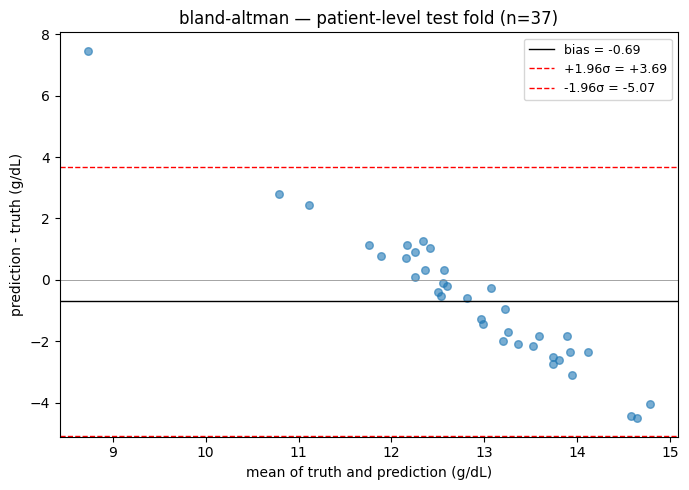

In [8]:
def bland_altman(truth, pred, title):
    truth = np.asarray(truth)
    pred = np.asarray(pred)
    avg = (truth + pred) / 2.0
    diff = pred - truth
    bias = float(diff.mean())
    sd = float(diff.std())
    loa_hi = bias + 1.96 * sd
    loa_lo = bias - 1.96 * sd

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(avg, diff, alpha=0.6, s=30)
    ax.axhline(bias, color='black', lw=1, label=f'bias = {bias:+.2f}')
    ax.axhline(loa_hi, color='red', ls='--', lw=1, label=f'+1.96σ = {loa_hi:+.2f}')
    ax.axhline(loa_lo, color='red', ls='--', lw=1, label=f'-1.96σ = {loa_lo:+.2f}')
    ax.axhline(0, color='grey', lw=0.5)
    ax.set_xlabel('mean of truth and prediction (g/dL)')
    ax.set_ylabel('prediction - truth (g/dL)')
    ax.set_title(title)
    ax.legend(loc='best', fontsize=9)
    plt.tight_layout()
    plt.show()

bland_altman(agg_test['hb'], agg_test['pred'],
             f'bland-altman — patient-level test fold (n={len(agg_test)})')

## takeaways

- **predict-the-mean is essentially the same as ridge on mean-RGB.** test patient-level MAE 1.77 (mean) vs 1.79 (ridge). global colour summaries don't add signal beyond what predicting the dataset mean already gives you on this split.
- that's *not* a failure — it's the floor we needed. it tells us where the predictive information lives: not in the global average colour of the nail crop, but in the **spatial structure** (sub-region pallor gradients, lunula visibility, texture at the nail edge, capillary patterning).
- a CNN is exactly the right tool for that. chunk 3 has to beat MAE ≈ 1.77 on the test fold — not by a hair, by a meaningful margin (target: < 1.3 g/dL patient-level MAE).
- residuals look roughly centred on zero in the bland-altman plot, which is good — no systematic over- or under-prediction. the spread is wide because the model is barely better than constant, which the plot also faithfully shows.